# Henry's Tutorial for TOAST

Date: 01 September 2026

---



# Basics of TOAST

In [101]:
import numpy as np
import astropy.units as u
from astropy.table import QTable
import pandas as pd

import toast

TOAST is built using an object-oriented approach to data management. The top level container is a `Data` object. Each `Data` object is made up of a list of `Observations`, which themselves contain information for a given `Telescope`. 

More on these objects will be introduced later, but for now, we need to define our telescope.

## Making a Telescope

The `Telescope` Object requires two vital pieces of information. 
- A telescope `Site`
- A `FocalPlane`

Let's define our telescope site:

TOAST has two built-in site classes (`GroundSite` and `SpaceSite`) built on the base class `Site`.

`GroundSite` defines a ground based site and requires a <span style="color:lightgreen">name, lat, long, alt</span>. Additionally, it can take in <span style="color:lightgreen">weather</span> data.

`SpaceSite` represents a telescope site with no atmosphere. It requires only a _name_ to define.

In [102]:

site = toast.instrument.GroundSite("atacama", "-22:57:30", "-67:47:10", 5200.0 * u.meter)

spacesite = toast.instrument.SpaceSite("HNSpaceTelescope")

Now we can define our `FocalPlane` object.

TOAST has multiple methods for creating focal plane models of varying complexity.

`toast.instrument_sim` has three functions for creating simulated focal planes:
- `fake_hexagon_focalplane` - creates a simple hexagon-packed focal plane. Not the most realistic but a simple implementation.
- `fake_rhombihex_focalplane` - creates a simple focal plane built up of 3 rhombi. Not the most realistic but a simple implementation. The number of pixels per rhombus (<span style="color:lightgreen">n_pix_rhombus</span>) must be a square number.
- `fake_boresight_focalplane` - Create a focalplane with all detectors at the boresight for testing.


In [103]:
from toast.instrument_sim import (
    fake_rhombihex_focalplane,
    fake_boresight_focalplane,
    fake_hexagon_focalplane,
    plot_focalplane
)

In [104]:
fp_fwhm = 30.0 * u.arcmin

focalplane = fake_rhombihex_focalplane(
    n_pix_rhombus=16,# Number of pixels per rhombus must be a perfect square
    width=8.0 * u.degree, # field of view of the focal plane
    gap=0 * u.radian,
    sample_rate=10.0 * u.Hz,
    epsilon=0.0,
    fwhm=fp_fwhm, # Beam size
    bandcenter=150 * u.GHz,
    bandwidth=20 * u.GHz,
    psd_net=300.0 * u.uK * np.sqrt(1 * u.second),
    psd_fmin=1.0e-5 * u.Hz,
    psd_alpha=1.0,
    psd_fknee=0.05 * u.Hz,
    fwhm_sigma=0.0 * u.arcmin,
    bandcenter_sigma=0 * u.GHz,
    bandwidth_sigma=0 * u.GHz,
    random_seed=123456,
)
fov = focalplane.field_of_view

<span style="color:red">Note:</span> This `FocalPlane` only considers one frequency band. For a dichroic/multichroic focal plane, it currently seems like you need to model another `FocalPlane` object.

We can plot that `FocalPlane` using:

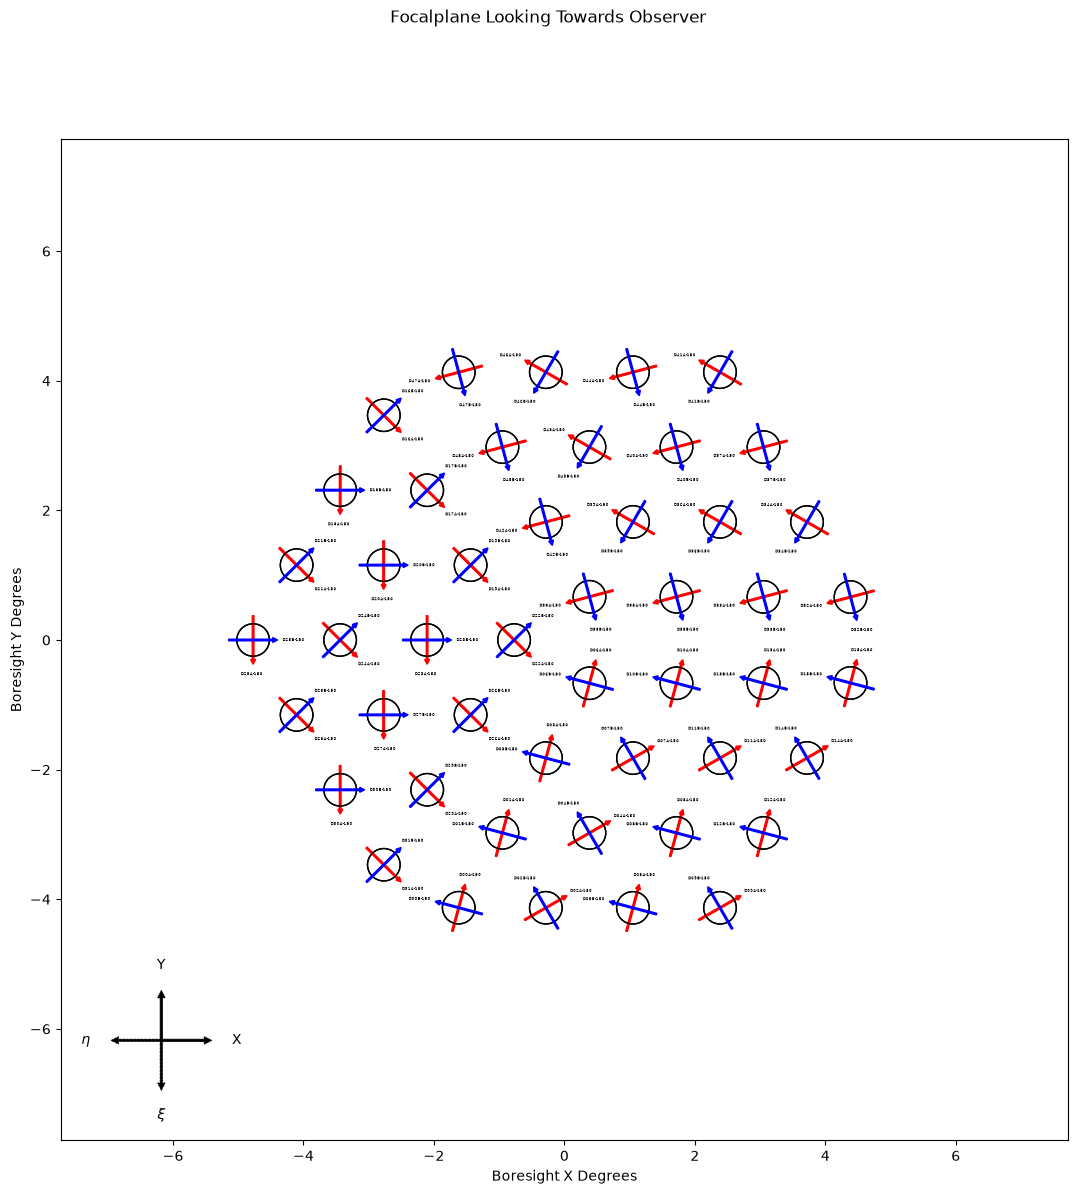

In [105]:
# We will define colors for our two polarization angles
detpolcol = {
    x: "red" if "A" in x else "blue" for x in focalplane.detectors
}

# Plot the focal plane
_ = plot_focalplane(
    focalplane=focalplane,
    width=1.3 * fov,
    height=1.3 * fov,
    show_labels=True,
    pol_color=detpolcol
)

Now that we have defined both our `FocalPlane` and out `Site`. We can make our `Telescope` object.

In [106]:
telescope = toast.Telescope(name="HenryTelescope", focalplane = focalplane, site = site)

## Exploring our Telescope

Now that we have made a `Telescope`. How do we access the information is stored in the object?

In [107]:
print(type(focalplane))
print(focalplane)

<class 'toast.instrument.Focalplane'>
<Focalplane: 96 detectors, sample_rate = 10.0 Hz, FOV = 9.9 deg, detectors = [D00A-150 .. D47B-150]>


In [108]:
print(focalplane.detectors)
print(focalplane.n_detectors)

[np.str_('D00A-150'), np.str_('D00B-150'), np.str_('D01A-150'), np.str_('D01B-150'), np.str_('D02A-150'), np.str_('D02B-150'), np.str_('D03A-150'), np.str_('D03B-150'), np.str_('D04A-150'), np.str_('D04B-150'), np.str_('D05A-150'), np.str_('D05B-150'), np.str_('D06A-150'), np.str_('D06B-150'), np.str_('D07A-150'), np.str_('D07B-150'), np.str_('D08A-150'), np.str_('D08B-150'), np.str_('D09A-150'), np.str_('D09B-150'), np.str_('D10A-150'), np.str_('D10B-150'), np.str_('D11A-150'), np.str_('D11B-150'), np.str_('D12A-150'), np.str_('D12B-150'), np.str_('D13A-150'), np.str_('D13B-150'), np.str_('D14A-150'), np.str_('D14B-150'), np.str_('D15A-150'), np.str_('D15B-150'), np.str_('D16A-150'), np.str_('D16B-150'), np.str_('D17A-150'), np.str_('D17B-150'), np.str_('D18A-150'), np.str_('D18B-150'), np.str_('D19A-150'), np.str_('D19B-150'), np.str_('D20A-150'), np.str_('D20B-150'), np.str_('D21A-150'), np.str_('D21B-150'), np.str_('D22A-150'), np.str_('D22B-150'), np.str_('D23A-150'), np.str_('D23

Detector information is stored in the `FocalPlane.detector_data` attribute. This is an `astropy.QTable` object and can be viewed using the astropy `show_in_notebook` method.

In [109]:
print(focalplane.properties)
print(type(focalplane.detector_data))
focalplane.detector_data.show_in_notebook()

['name', 'quat', 'pol_leakage', 'psi_pol', 'gamma', 'fwhm', 'psd_fmin', 'psd_fknee', 'psd_alpha', 'psd_net', 'bandcenter', 'bandwidth', 'pixel', 'uid', 'pol_angle', 'pol_efficiency']
<class 'astropy.table.table.QTable'>


DataGrid(auto_fit_params={'area': 'all', 'padding': 30, 'numCols': None}, corner_renderer=None, default_render…

Another useful focal plane function is the `detector_groups` method. 

This selects a column of the `detector_data` and returns a dictionary where the keys are the unique values in that column, and the values are the corresponding detector names.

In [110]:
# For example, we can split our detectors by polarization
psi_pol_dict = focalplane.detector_groups(column='psi_pol')
print(f"This dictionary has two keys, one for each polarization state {psi_pol_dict.keys()}")
psi_pol_list = list(psi_pol_dict.items())
print(f"The detectors corresponding to polarization state: {psi_pol_list[0][0]} are\n{psi_pol_list[0][1]}")

This dictionary has two keys, one for each polarization state dict_keys([<Quantity 0. rad>, <Quantity 1.57079633 rad>])
The detectors corresponding to polarization state: 0.0 rad are
[np.str_('D00A-150'), np.str_('D01A-150'), np.str_('D02A-150'), np.str_('D03A-150'), np.str_('D04A-150'), np.str_('D05A-150'), np.str_('D06A-150'), np.str_('D07A-150'), np.str_('D08A-150'), np.str_('D09A-150'), np.str_('D10A-150'), np.str_('D11A-150'), np.str_('D12A-150'), np.str_('D13A-150'), np.str_('D14A-150'), np.str_('D15A-150'), np.str_('D16A-150'), np.str_('D17A-150'), np.str_('D18A-150'), np.str_('D19A-150'), np.str_('D20A-150'), np.str_('D21A-150'), np.str_('D22A-150'), np.str_('D23A-150'), np.str_('D24A-150'), np.str_('D25A-150'), np.str_('D26A-150'), np.str_('D27A-150'), np.str_('D28A-150'), np.str_('D29A-150'), np.str_('D30A-150'), np.str_('D31A-150'), np.str_('D32A-150'), np.str_('D33A-150'), np.str_('D34A-150'), np.str_('D35A-150'), np.str_('D36A-150'), np.str_('D37A-150'), np.str_('D38A-150'

## Your First Observation